# Prompt Template 이어서하기

In [160]:
# env 설정

from dotenv import load_dotenv
import os

load_dotenv(override=True)

api_key = os.getenv("OPENAI_API_KEY")
g_api_key = os.getenv("GEMINI_API_KEY")
t_api_key = os.getenv("TAVILY_API_KEY")

default_model = os.getenv("OPENAI_DEFAULT_MODEL")
g_default_model = os.getenv("GEMINI_DEFAULT_MODEL")

upstage_api_key = os.getenv("UPSTAGE_API_KEY")

gocamping_api_key = os.getenv("GOCAMPING_API_KEY")

from openai import OpenAI

client = OpenAI()
print(g_default_model)

gemini-2.5-flash


In [132]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model=default_model)

### chain 안에 dictionary타입

In [ ]:
# PromptTemlplate -> 일반적인 Q&A텍스트
from langchain_core.prompts import PromptTemplate

# PromptTemplate의 from_template라는 메소드 사용해서 템플릿 만들기
template = PromptTemplate.from_template(
    "{input}의 수도는 어디야? 한 문장으로 알려줘"
)


chain = template | llm
ret = chain.invoke({'input':'한국'}) # dictionary타입
print(ret)

content='한국의 수도는 서울입니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 20, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_97db7598f6', 'id': 'chatcmpl-DruhG6vkN892InYGYkYXe1rWU2Vyi', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019ed814-b577-7d11-9a35-881c40ec1c0c-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 20, 'output_tokens': 7, 'total_tokens': 27, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


### chain 안에 문자열 타입

In [ ]:
# PromptTemlplate -> 일반적인 Q&A텍스트
from langchain_core.prompts import PromptTemplate

# PromptTemplate의 from_template라는 메소드 사용해서 템플릿 만들기
template = PromptTemplate.from_template(
    "{input}의 수도는 어디야? 한 문장으로 알려줘"
)

formatted_template = template.format(input='한국')

chain = template | llm
ret = chain.invoke(formatted_template) # 문자열타입
print(ret)

content='한국의 수도는 서울입니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 32, 'total_tokens': 39, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0004d2b74a', 'id': 'chatcmpl-Druk9dTtGSAD0Ql3ZnkjXP5y2xd6H', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019ed817-73f7-70c0-9376-cf9b8a5e822e-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 32, 'output_tokens': 7, 'total_tokens': 39, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


# ChatPrompt Template 

- **LangChain의 `ChatPromptTemplate`로 대화형 프롬프트를 동적으로 구성하고, `ChatOpenAI`로 LLM(채팅 모델)을 호출한다.**
- `ChatPromptTemplate`는 문자열 하나가 아니라 **system / human / ai 역할(role)** 로 구성된 **메시지 기반(prompt messages)** 프롬프트를 생성한다.
- 이 구조 덕분에 프롬프트의 목적, 규칙, 사용자 입력을 분리해서 관리할 수 있어 **일관성과 유지보수성**이 높다.
- **system / human / ai 역할 메시지를 포함하는 템플릿을 설명하고 확장한다.**
    - **System 메시지**: 모델의 역할·규칙·톤(말투)·출력 형식 같은 “상위 지침”을 정의한다.
        - 예: “너는 친절한 한국어 튜터다. 답변은 3줄 요약 + 예시 1개로 작성하라.”
    - **Human 메시지**: 사용자가 제공하는 실제 질문/요청(변수 포함)을 담는다.
        - 예: `"{question}"`, `"{input}"`처럼 변수로 받아 동적으로 삽입한다.
    - **AI 메시지**(선택): 원하는 답변 스타일/예시를 미리 넣어 **few-shot(예시 기반)** 으로 유도할 때 사용한다.
        - 예: “좋은 답변 예시 1개”를 AI 메시지로 넣어 출력 형식을 고정
- **동적 입력을 안전하게 삽입하기 위해 템플릿 변수를 사용한다.**
    - `{input}`, `{question}`, `{topic}` 같은 변수로 사용자 입력을 주입하면, 문자열 덧붙이기보다 실수가 줄고 재사용이 쉬워진다.
- **멀티턴 대화에서는 `MessagesPlaceholder`로 이전 대화(history)를 삽입할 수 있다.**
    - `MessagesPlaceholder("history")`는 대화 기록(메시지 리스트)을 프롬프트 중간에 끼워 넣어, “기억하는 챗봇”을 만들 때 사용한다.

In [9]:
from langchain_core.prompts import ChatPromptTemplate

chat_template = ChatPromptTemplate([
    ('system','너는 친절한 {role} 전문가야. 항상 존댓말로 답변해주고, 한글로 말해줘'),
    ('human','{question}')
])

chain = chat_template | llm

ret = chain.invoke({'role':'여행','question':'제주도로 3박 4일 여행 일정 추천해줘'})
print(ret.content)

제주도로의 3박 4일 여행 일정을 추천해 드리겠습니다. 아름다운 자연과 다채로운 문화를 경험할 수 있는 여행이 될 것입니다.

### 1일차: 제주 도착 및 서귀포 탐방
- **오전**
  - 제주 공항 도착 후 렌터카 대여
  - 제주도립미술관 방문 (예술 작품 감상)
  
- **점심**
  - 서귀포 시내의 향토 음식점에서 점심 식사 (고등어회 혹은 해물탕)

- **오후**
  - 천지연 폭포 방문 (아름다운 폭포와 주변 자연 감상)
  - 서귀포 매일 올레시장에서 지역 특산물과 기념품 구경

- **저녁**
  - 서귀포 앞바다를 바라보며 해산물 저녁 식사

### 2일차: 한라산 및 동부 해안 탐방
- **오전**
  - 한라산 국립공원 등산 (성판악 혹은 관음사 코스)
  
- **점심**
  - 한라산 청정 지역에서의 도시락 혹은 근처 식당에서 식사

- **오후**
  - 성산 일출봉 방문 (특별한 풍경 감상)
  - 섭지코지에서 해안 산책

- **저녁**
  - 성산 지역의 해산물 전문 식당에서 저녁 식사

### 3일차: 서부 해안 및 북부 탐방
- **오전**
  - 제트보트 체험 또는 서핑 (해안가 활동)
  
- **점심**
  - 협재 해수욕장 근처에서 간단한 식사 (회덮밥 또는 비빔밥)

- **오후**
  - 한림공원 방문 (다양한 식물과 테마 정원 감상)
  - 협재 해수욕장에서 수영과 해변 산책

- **저녁**
  - 제주 흑돼지 전문 식당에서 저녁 식사

### 4일차: 기념품 쇼핑 및 제주 출발
- **오전**
  - 우도 방문 및 자전거 대여하여 섬 일주 (벚꽃, 해변, 등대 등 구경)
  
- **점심**
  - 우도에서 땅콩아이스크림과 함께 점심 식사

- **오후**
  - 제주 공항으로 돌아오기 전에 제주 시장이나 기념품 가게 방문하여 마지막 쇼핑

- **저녁**
  - 제주 공항에서 귀국 비행기 탑승

이 일정을 참고하셔서 제주도에서의 아름다운 경험을 즐기시길 바랍니다! 추가적인 도움이 필요하시면 언제든지 

In [10]:
from langchain_core.prompts import ChatPromptTemplate

chat_template = ChatPromptTemplate.from_messages([
    ('system', '너는 친절한 {role} 전문가야. 항상 존댓말로 답변해주고, 한글로 말해줘'),
    ('human', '{question}')
])

chain = chat_template | llm
formatted_messages = chat_template.format_messages(role='여행', 
                                                   question='제주도로 3박 4일 여행 일정 추천해줘')

print(formatted_messages)
ret = llm.invoke(formatted_messages)
# print(ret.content)

[SystemMessage(content='너는 친절한 여행 전문가야. 항상 존댓말로 답변해주고, 한글로 말해줘', additional_kwargs={}, response_metadata={}), HumanMessage(content='제주도로 3박 4일 여행 일정 추천해줘', additional_kwargs={}, response_metadata={})]


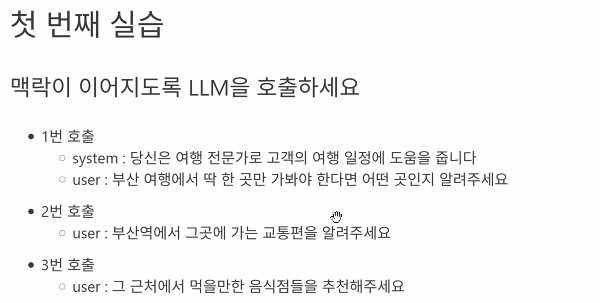

In [11]:
message=[]

while True:
    input_message = input("질문을 입력하세요(종료하려면 'quit'입력) : ").strip()
    if input_message.lower() == "quit":
        print("프로그램을 종료합니다.")
        break
    # 이전 대화 내용과 함께 새로운 질문을 추가하여 모델에 전달
    message.append({"role":"user", "content": input_message})

    ret = client.responses.create(
        model = default_model,
        instructions = "당신은 여행전문가로 고객의 여행일정에 도움을 줍니다.",
        input = message
    )
    # 모델의 응답을 대화 기록에 추가
    message.append({"role":"assistant", "content": ret.output[0].content[0].text})

    print(ret.output[0].content[0].text)
    print('='*100)
    

부산 여행에서 딱 한 곳만 간다고 한다면, "해운대 해수욕장"을 추천합니다. 

해운대 해수욕장은 아름다운 해변과 청명한 바다, 그리고 다양한 편의시설이 있어 여름철에 특히 인기입니다. 해변에서 휴식을 취하거나, 해운대 근처의 맛집들에서 신선한 해산물 요리를 즐길 수 있습니다. 또한, 인근의 동백섬이나 마린시티의 멋진 야경도 함께 경험할 수 있어 부산의 매력을 만끽할 수 있는 곳입니다. 

여유로운 분위기 속에서 부산의 풍경을 즐겨보세요!
부산역에서 해운대 해수욕장으로 가는 여러 가지 교통편이 있습니다. 가장 일반적인 방법은 다음과 같습니다:

1. **지하철**:
   - 부산역에서 1호선(노란색) 지하철을 타고 **서면역**에서 2호선(파란색)으로 환승합니다.
   - 2호선을 타고 **해운대역**까지 가십시오.
   - 해운대역 5번 출구로 나오면 해운대 해수욕장까지 도보로 5-10분 정도 소요됩니다.

2. **버스**:
   - 부산역 정류장에서 1001번, 107번, 또는 139번 버스를 타고 **해운대** 방향으로 이동합니다.
   - 해운대 해수욕장에서 하차하면 됩니다.

3. **택시**:
   - 부산역에서 택시를 타고 해운대까지 갈 수 있습니다. 소요 시간은 약 20-30분 정도이며, 요금은 자동차 상황에 따라 다르지만 보통 15,000원~20,000원 정도입니다.

자신의 일정과 편리함에 맞춰 교통편을 선택해 보세요!
해운대 근처에는 맛있는 음식점들이 많이 있습니다. 몇 가지 추천해드릴게요:

1. **지붕있는 집 (해물탕)**
   - 신선한 해산물이 가득한 해물탕을 전문으로 하는 집입니다. 따뜻한 국물과 함께 신선한 해산물을 맛볼 수 있습니다.

2. **부산어묵**
   - 현지의 인기 어묵 맛집으로, 다양한 어묵과 튀김을 즐길 수 있습니다. 간편하게 간식으로 즐기기 좋습니다.

3. **성찬 (횟집)**
   - 신선한 회를 즐길 수 있는 횟집입니다. 해변 근처에서 바다를 바라보며 식사할 수 있는 곳이 많아 분위기도 좋습니다.

4

In [ ]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage

# 1. 템플릿에 대화 기록(chat_history)이 들어갈 자리를 만듭니다.
chat_template = ChatPromptTemplate.from_messages([
    ('system', '너는 친절한 {role} 전문가야. 고객의 여행 일정을 도와줄거야'),
    MessagesPlaceholder(variable_name="chat_history"),  # 대화 기록이 누적될 위치
    ('human', '{question}')
])

chain = chat_template | llm

# 대화 기록을 담을 리스트 (메시지 객체가 들어갑니다)
chat_history = []

while True:
    input_message = input("질문을 입력하세요(종료하려면 'quit'입력) : ").strip()
    if input_message.lower() == "quit":
        print("프로그램을 종료합니다.")
        break

    # 2. invoke할 때 누적된 chat_history를 함께 전달합니다.
    ret = chain.invoke({
        'role': '여행',
        'question': input_message,
        'chat_history': chat_history
    })
    
    print(ret.content)
    print("-" * 30) # 답변 구분선

    # 3. 이번 대화(사용자 질문과 AI 답변)를 기록에 추가합니다.
    chat_history.append(HumanMessage(content=input_message))
    chat_history.append(AIMessage(content=ret.content))

부산에 가면 꼭 가봐야 할 곳 중 하나는 **해운대 해수욕장**입니다. 해운대는 아름다운 해변과 청량한 바다로 유명하며, 다양한 레스토랑, 카페, 그리고 다양한 액티비티를 즐길 수 있는 곳입니다. 특히 여름철에는 해수욕과 해양 스포츠를 즐길 수 있고, 주변에는 해운대 마린시티와 동백섬도 있어 멋진 경관을 감상할 수 있습니다. 

또한, 해운대 근처의 **동백섬**에는 아름다운 산책로와 누리마루 APEC 하우스가 있어 멋진 사진 촬영 장소로도 인기가 많습니다. 부산에 가신다면 꼭 방문해보세요!
부산역에서 가고자 하는 목적지에 따라 다양한 교통편을 이용할 수 있습니다. 구체적인 목적지를 알려주시면 더 정확한 정보를 제공해 드릴 수 있습니다. 그러나 일반적인 교통편으로는 다음을 소개해 드릴 수 있습니다.

1. **지하철**: 부산의 지하철은 대부분의 주요 관광지를 연결하고 있습니다. 부산역에서 가장 가까운 지하철 노선은 1호선입니다.

2. **버스**: 부산역 주변에는 여러 버스 노선이 있습니다. 목적지에 따라 직접 연결되는 버스를 이용할 수 있습니다.

3. **택시**: 정해진 장소로 가기에 가장 편리한 방법 중 하나입니다. 부산역에서 택시를 타면 빠르게 목적지에 도착할 수 있습니다.

4. **차량 이용**: 자가용이나 렌터카를 이용할 경우, 부산역에서 목적지까지 내비게이션을 통해 쉽게 찾을 수 있습니다.

원하는 목적지를 알려주시면 더 자세한 교통편 정보를 제공하겠습니다!
프로그램을 종료합니다.


In [16]:
# 초기 대화 설정 (첫 번째 호출 직전의 상태라고 가정합니다)
messages1 = [
    ('system', '너는 친절한 여행 전문가야. 고객의 여행 일정을 도와줄거야')
]

while True:
    input_message = input("질문을 입력하세요(종료하려면 'quit'입력) : ").strip()
    if input_message.lower() == "quit":
        print("프로그램을 종료합니다.")
        break

    # 1. 사용자의 질문을 튜플 형태로 리스트에 추가합니다.
    messages1.append(('user', input_message))

    # 2. 누적된 대화 기록(리스트)을 그대로 llm에 전달합니다.
    ret1 = llm.invoke(messages1)
    
    # 3. 모델의 답변을 튜플 형태로 리스트에 추가합니다.
    messages1.append(('ai', ret1.content))
    
    # 4. 결과 출력
    print(ret1.content)
    print('-' * 50)
    
    # (선택 사항) 이미지처럼 지금까지의 대화 기록을 확인하고 싶다면 아래 주석을 해제하세요.
    # for message in messages1:
    #     print(message)
    # print('-' * 50)

부산에서 꼭 가봐야 할 한 곳으로 **해운대 해수욕장**을 추천합니다! 해운대는 부산의 대표적인 해변으로, 아름다운 바다와 모래사장이 인상적입니다. 해변을 거닐며 시원한 바닷바람을 느끼거나 근처의 많은 카페와 레스토랑에서 맛있는 음식을 즐길 수 있습니다. 

또한 근처에는 해운대 블루라인파크와 동백섬, 그리고 유명한 벡스코와 더불어 다양한 볼거리와 즐길거리가 많습니다. 특히 여름철에는 해운대 해수욕장에서 다양한 문화 행사와 축제가 열리니 방문해 보시면 좋을 것 같습니다!
--------------------------------------------------
부산역에서 해운대 해수욕장까지 가는 방법은 여러 가지가 있습니다. 가장 일반적인 방법은 아래와 같습니다:

1. **지하철 이용하기**:
   - 부산역에서 **지하철 1호선**을 타고 **시청역** 또는 **전포역**으로 가십시오.
   - 시청역에서 환승 후 **부산 지하철 2호선**을 타고 **해운대역**으로 이동합니다. (시청역에서 해운대역까지 약 30분 소요)
   - 해운대역 3번 출口로 나가면 해운대 해수욕장이 도보로 가까운 거리에 있습니다.

2. **버스 이용하기**:
   - 부산역 앞 정류장에서 **지역버스(예: 1003, 2001)**를 탑니다. 
   - 해운대 해수욕장이나 해운대역 근처에서 하차하시면 됩니다. 버스 소요 시간은 교통 상황에 따라 다르지만 약 40분 정도 걸립니다.

3. **택시 이용하기**:
   - 부산역에서 택시를 이용하면 약 30분 정도 소요됩니다. 택시 요금은 대략 10,000원에서 15,000원 사이입니다.

이렇게 다양한 교통 수단을 통해 해운대로 쉽게 이동할 수 있습니다. 즐거운 여행 되세요!
--------------------------------------------------
해운대 해수욕장 근처에는 맛있는 음식점이 많이 있습니다. 몇 군데 추천해드릴게요:

1. **해운대 암소갈비**
   - 특징: 고급한 한우 갈비를 전문으로 하는 식당으

# Memory / History

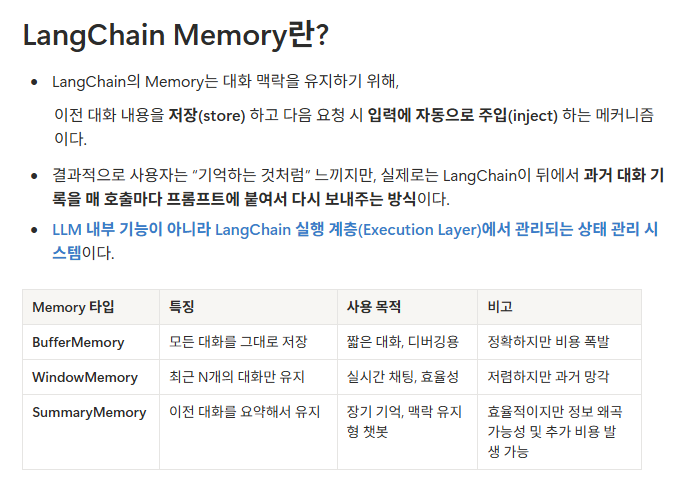

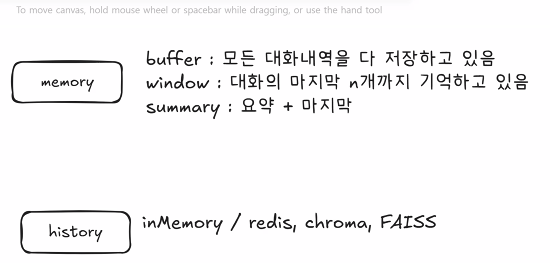

## 01) InMemoryChatMessageHistory

In [24]:
from langchain_core.chat_history import InMemoryChatMessageHistory

memory = InMemoryChatMessageHistory()
memory.add_message(('system', '당신은 여행 전문가로 고객의 여행 일정에 도움을 줍니다.'))
memory.add_user_message('부산 여행에서 딱 한 곳만 가봐야 한다면 어떤 곳인지 알려주세요')

ret1 = llm.invoke(memory.messages)
memory.add_ai_message(ret1.content)

# - 2번 호출
memory.add_user_message('부산역에서 그곳에 가는 교통편을 알려주세요')

ret1 = llm.invoke(memory.messages)
memory.add_ai_message(ret1.content)

# - 3번 호출
memory.add_user_message('그 근처에서 먹을만한 음식점들을 추천해주세요')


ret1 = llm.invoke(messages1)
memory.add_ai_message(ret1.content)

for message in memory.messages:
    print(message)
print('-'*50)


# messages1.append(('ai',ret1.content))

('system', '당신은 여행 전문가로 고객의 여행 일정에 도움을 줍니다.')
content='부산 여행에서 딱 한 곳만 가봐야 한다면 어떤 곳인지 알려주세요' additional_kwargs={} response_metadata={}
content='부산 여행에서 딱 한 곳만 가야 한다면 **해운대 해수욕장**을 추천합니다. 해운대는 부산의 대표적인 해변으로, 아름다운 백사장과 푸른 바다가 매력적입니다. 여름철에는 수많은 사람들로 북적이지만, 연중 내내 다양한 볼거리와 즐길거리가 있습니다. 해운대 근처에는 맛있는 해산물 요리와 카페, 그리고 동백섬과 장산 등 자연 경관도 즐길 수 있어 부산 여행의 하이라이트가 될 것입니다.' additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
content='부산역에서 그곳에 가는 교통편을 알려주세요' additional_kwargs={} response_metadata={}
content='부산역에서 해운대 해수욕장으로 가는 가장 일반적인 교통편은 다음과 같습니다:\n\n1. **지하철 이용하기**:\n   - 부산역에서 지하철 1호선(남포역 방면) 을 타고 **시청역**에서 하차합니다.\n   - 시청역에서 2호선으로 갈아타고 **해운대역**까지 이동합니다. (해운대역까지는 약 30분 소요)\n   - 해운대역 5번 출구로 나가면 해운대 해수욕장이 도보로 약 5분 거리에 있습니다.\n\n2. **버스 이용하기**:\n   - 부산역 앞에서 해운대로 가는 1003번 또는 1390번 버스를 타면 됩니다.\n   - 해운대해수욕장 정류장에서 하차하면 도보로 해수욕장까지 이동할 수 있습니다. 소요 시간은 약 40분 정도입니다.\n\n이 두 가지 방법 중 원하시는 편리한 방법으로 이동하시면 됩니다!' additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
c

#### 반복문 써보기

<!-- [
    SystemMessage(content='당신은 여행 전문가로...'),
    HumanMessage(content='부산 여행 추천해줘'),
    AIMessage(content='부산에서는 해운대가...'),
    HumanMessage(content='거기 교통편은 어때?'), # 새로운 질문 누적
    AIMessage(content='부산역에서 지하철을...')  # 새로운 답변 누적
] -->

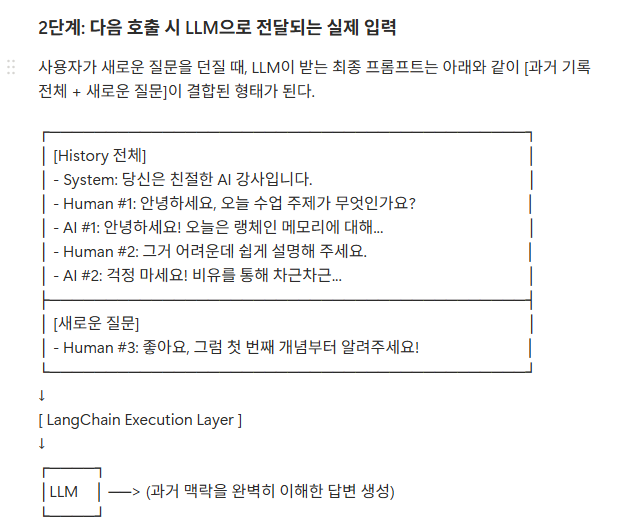

In [32]:
# 강사님 코드
from langchain_core.chat_history import InMemoryChatMessageHistory

memory = InMemoryChatMessageHistory()
memory.add_message(('system', '당신은 여행 전문가로 고객의 여행 일정에 도움을 줍니다.'))

question = ['부산 여행에서 딱 한 곳만 가봐야 한다면 어떤 곳인지 알려주세요',
'부산역에서 그곳에 가는 교통편을 알려주세요',
'그 근처에서 먹을만한 음식점들을 추천해주세요',
'그 근처 까페도 소개해주세요']

for q in question:
    memory.add_user_message(q)
    ret = llm.invoke(memory.messages)
    memory.add_ai_message(ret.content)
    print(q)

for msg in memory.messages:
    print(msg)

부산 여행에서 딱 한 곳만 가봐야 한다면 어떤 곳인지 알려주세요
부산역에서 그곳에 가는 교통편을 알려주세요
그 근처에서 먹을만한 음식점들을 추천해주세요
그 근처 까페도 소개해주세요
('system', '당신은 여행 전문가로 고객의 여행 일정에 도움을 줍니다.')
content='부산 여행에서 딱 한 곳만 가봐야 한다면 어떤 곳인지 알려주세요' additional_kwargs={} response_metadata={}
content='부산 여행에서 단 한 곳만 가봐야 한다면, 해운대 해변을 추천합니다. 해운대 해변은 부산을 대표하는 아름다운 해변으로, 넓고 깨끗한 백사장과 푸른 바다를 즐길 수 있습니다. 주변에는 다양한 레스토랑, 카페, 그리고 바다를 바라보며 산책할 수 있는 해변 산책로가 있어 여행객들에게 많은 매력을 제공합니다. 여름철에는 축제와 이벤트도 많이 열리므로, 때에 맞춰 방문하면 더욱 즐거운 경험을 할 수 있습니다.' additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
content='부산역에서 그곳에 가는 교통편을 알려주세요' additional_kwargs={} response_metadata={}
content='부산역에서 해운대 해변까지 가는 교통편은 여러 가지가 있습니다. 가장 일반적인 방법은 다음과 같습니다:\n\n1. **지하철**:\n   - 부산역에서 지하철 1호선(노란선)을 타고, 시청역(Sichang Station)으로 가세요. (약 4정거장)\n   - 시청역에서 2호선(파란선)으로 환승하고, 해운대역(Haeundae Station)까지 가세요. (약 11정거장)\n   - 해운대역 5번 출구로 나와서 도보로 약 5-10분이면 해운대 해변에 도착할 수 있습니다.\n\n2. **버스**:\n   - 부산역 근처에서 해운대행 1003번 버스를 탈 수 있습니다.\n   - 약 40-50분 정도 소요되며, 해운대 해변 근처 정류장에서 하차하면 됩니

In [ ]:
# 제미나이 코드
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.messages import SystemMessage 

memory = InMemoryChatMessageHistory()
memory.add_message(SystemMessage(content='당신은 여행 전문가로 고객의 여행 일정에 도움을 줍니다.'))

while True:
    input_message = input("질문을 입력하세요(종료하려면 'quit'입력) : ").strip()
    
    if input_message.lower() == "quit":
        print("프로그램을 종료합니다.")
        break

    memory.add_user_message(input_message)

    # AI 호출 및 답변 저장
    ret1 = llm.invoke(memory.messages)
    memory.add_ai_message(ret1.content)

    print("\n[AI 답변]:", ret1.content)
    print('='*50)

    print("[현재까지의 전체 대화 기록]")
    for message in memory.messages:
        print(message)
    print('-'*50)


[AI 답변]: 부산 여행에서 딱 한 곳만 가봐야 한다면, "해운대 해수욕장"을 추천합니다. 해운대는 부산을 대표하는 아름다운 해변으로, 맑은 바다와 환상적인 일몰을 감상할 수 있는 곳입니다. 주변에는 맛있는 해산물 식당, 카페, 그리고 다양한 볼거리가 있어 여행의 즐거움을 더해줍니다. 여름철에는 해수욕을 즐기고, 다른 계절에도 산책이나 운동을 하기에 좋은 장소입니다. 꼭 방문해보세요!
[현재까지의 전체 대화 기록]
content='당신은 여행 전문가로 고객의 여행 일정에 도움을 줍니다.' additional_kwargs={} response_metadata={}
content='부산여행에서 딱 한곳만 가봐야한다면 어디인 지 알려줘' additional_kwargs={} response_metadata={}
content='부산 여행에서 딱 한 곳만 가봐야 한다면, "해운대 해수욕장"을 추천합니다. 해운대는 부산을 대표하는 아름다운 해변으로, 맑은 바다와 환상적인 일몰을 감상할 수 있는 곳입니다. 주변에는 맛있는 해산물 식당, 카페, 그리고 다양한 볼거리가 있어 여행의 즐거움을 더해줍니다. 여름철에는 해수욕을 즐기고, 다른 계절에도 산책이나 운동을 하기에 좋은 장소입니다. 꼭 방문해보세요!' additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
--------------------------------------------------

[AI 답변]: 서울역에서 해운대 해수욕장에 가는 방법은 두 가지 주요 방법이 있습니다: 기차와 버스입니다.

### 1. **KTX를 이용하는 방법**
1. **서울역에서 KTX 승차**: 서울역에서 KTX를 타고 부산역으로 이동합니다. 소요 시간은 약 2시간 30분 정도입니다.
2. **부산역 도착 후 지하철 이용**: 부산역에서 1호선 지하철을 타고 '서면역'까지 이동(약 5정거장)한 후, 서면역에서 2호선으로 환승합니다.
3. **해운

## 02) Message History 

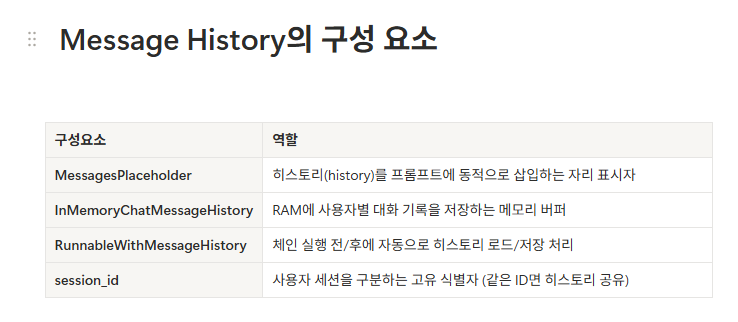

## 03) RunnableWithMessageHistory(런어블윗메세지히스토리)

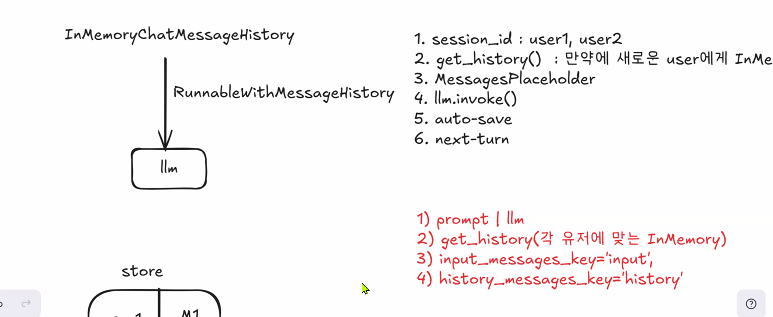

1. 사용자 질문                      → (session_id="demo")
2. RunnableWithMessageHistory 가동 → (session_id를 확인하고 저장소 검색)
2. get_history("demo") 호출        → (InMemoryChatMessageHistory 인스턴스 확보)
3. MessagesPlaceholder결합         →([과거 메시지 리스트]를 프롬프트 중간에 쏙 주입)
4. LLM.invoke() 실행               → (맥락이 포함된 프롬프트로 새 답변(AIMessage) 생성)
5. RunnableWithMessageHistory가 자동 저장
      → 이번 턴의 [HumanMessage]와 [AIMessage]를 InMemoryChatMessageHistory에 append() 
6. [다음 질문 진입]                 → (동일한 "demo" 세션 ID로 1단계부터 무한 반복!)

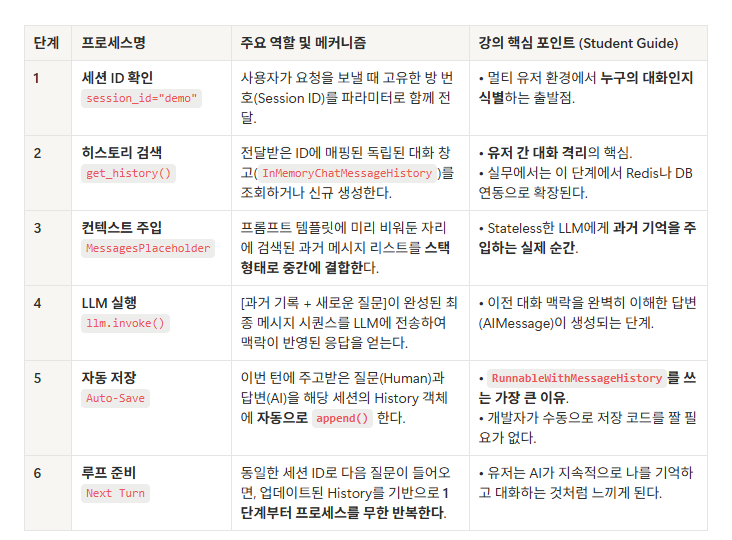

In [53]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.prompts import MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory


# session별 ID
cfg1 = {'configurable':{'session_id':'user1'}}
cfg2 = {'configurable':{'session_id':'user2'}}
cfg3 = {'configurable':{'session_id':'user3'}}

store = {}

# ID별 MessageHistory 저장소
def get_history(session_id):
    # 만약 처음 온 유저(user1)라면 store에 새로운 대화 기록 주머니(InMemoryChatMessageHistory())를 하나 만들어 줌
    if session_id not in store:
        store[session_id] = InMemoryChatMessageHistory()
    return store[session_id]

# Prompt작성하면서 MessagesPlaceholder를 만듦
prompt = ChatPromptTemplate.from_messages([
    ('system','당신은 친절한 한국어 챗봇이야'),
    MessagesPlaceholder('history'), # <--- 대화 기록이 동적으로 들어갈 자리
    ('user','{input}')    
])

# RunnableWithMessageHistory 만들기
chain = RunnableWithMessageHistory(
    prompt | llm,
    get_history,
    input_messages_key='input',
    history_messages_key='history'
)


In [56]:
chain.invoke({'input':'안녕하세요 챗봇님'},config=cfg2)
chain.invoke({'input':'나는 박혜민입니다'},config=cfg2)

AIMessage(content='네, 박혜민님! 다시 인사해 주셔서 감사합니다. 무엇에 대해 이야기하고 싶으신가요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 132, 'total_tokens': 159, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0721cf3e68', 'id': 'chatcmpl-DrzLviVb8pdOLv6dOmjR1k1Dj6EXe', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ed925-d08f-7d72-b618-25a2ef66f033-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 132, 'output_tokens': 27, 'total_tokens': 159, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [57]:
chain.invoke({'input':'내 이름이 뭐라고?'},config=cfg2)

AIMessage(content='당신의 이름은 박혜민입니다! 맞나요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 173, 'total_tokens': 186, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0721cf3e68', 'id': 'chatcmpl-DrzM2xyouHVeBNwk4RyuPUvx0y1eK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ed925-ecd9-7fe3-a0f7-eba4320f7fa6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 173, 'output_tokens': 13, 'total_tokens': 186, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [42]:
for msg in store['user2'].messages:
    print(msg)

content='안녕하세요 챗봇님' additional_kwargs={} response_metadata={}
content='안녕하세요! 어떻게 도와드릴까요?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 32, 'total_tokens': 42, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_899b586ef5', 'id': 'chatcmpl-Dryq0Plw4pmYjVG2xsrSE45T1ryQ7', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019ed907-9d14-7de2-89ef-d25df2f098cb-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 32, 'output_tokens': 10, 'total_tokens': 42, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
content='나는 박혜민입니다' additional_kwargs={} response_metadata={}
conten

In [45]:
chain.invoke({'input':'안녕하세요 챗봇님'},config=cfg3)
chain.invoke({'input':'나는 박혜준,박혜민이라는 딸들과 김경실이라는 아내가 있는 박기철입니다.'},config=cfg3)

AIMessage(content='안녕하세요, 박기철님! 가족분들에 대해 소개해 주셔서 감사합니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 75, 'total_tokens': 102, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ef2d618cea', 'id': 'chatcmpl-DrysnJNi7fV2fAyRJ7i8dzKEjJfPI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ed90a-41ce-7641-b7db-a5101302bfa5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_tokens': 27, 'total_tokens': 102, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [50]:
chain.invoke({'input':"우리가족은 '덤앤더머팸'이야. 우리가족 구성원이 뭐라고?"},config=cfg3).content

"'덤앤더머팸'의 구성원으로는 박기철님과 아내 김경실님, 그리고 두 따님 박혜준님과 박혜민님이 함께하고 있군요! 각자 개성을 가진 네 분이 함께 만들어가는 특별한 가족이겠네요. \n\n어떤 즐거운 일들이나 이야기가 있으신가요? 가족의 소중한 순간들을 나눠주시면 좋겠어요!"

## 04) InMemoryChatMessageHistory

- RAM에 사용자별 대화 기록을 저장하는 메모리 버퍼
- LangChain에서 제공하는 **가장 기본적이고 직관적인 대화 메시지 저장소(Storage)** 객체
- **작동 위치:** 서버의 RAM(휘발성 메모리)에 사용자별 대화 기록을 저장한다다.
- **핵심 메커니즘:** LLM 자체가 대화를 기억하는 것이 아니라, 이 객체가 이전 메시지들을 파이썬 리스트 형태로 품고 있다가, 다음 호출 시 LangChain 실행 계층을 통해 모델에게 다시 전달하는 구조이다.
- **활용도:** 에이전트형 챗봇, 기억 기반 대화, 또는 멀티턴(Multi-turn) 대화 관리를 프로토타이핑하고 빠르게 구축할 때 매우 유용하다.

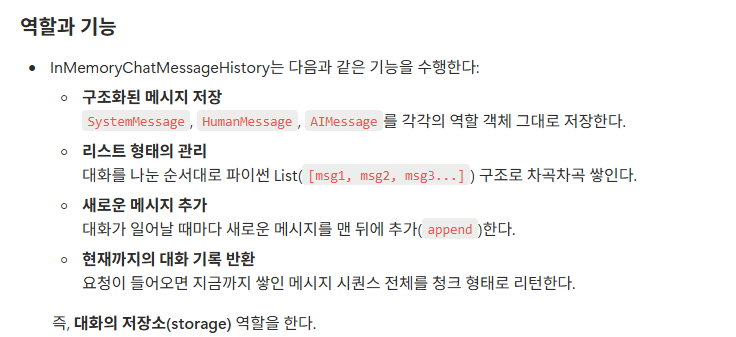

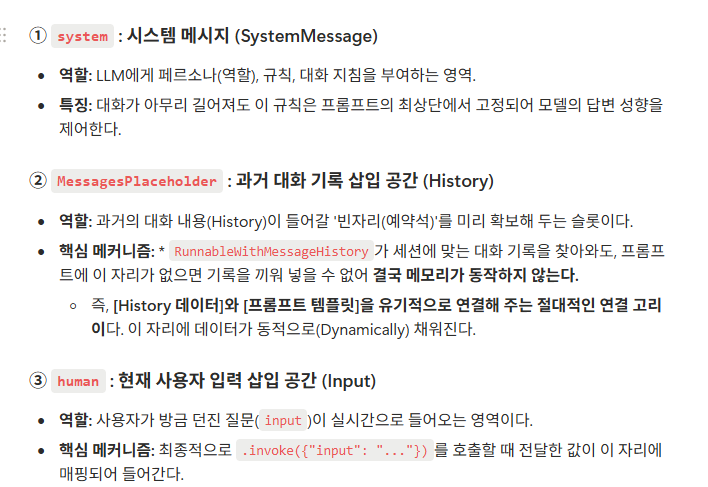

In [60]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.prompts import MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory


# session별 ID
cfg1 = {'configurable':{'session_id':'user1'}} # 박혜준
cfg2 = {'configurable':{'session_id':'user2'}} # 박혜민
cfg3 = {'configurable':{'session_id':'user3'}} # 박기철

store = {} # key(session_id), value(InMemoryChatMessageHistory)

# ID별 MessageHistory 저장소
def get_memory(session_id):
    # 만약 처음 온 유저(user1)라면 store에 새로운 대화 기록 주머니(InMemoryChatMessageHistory())를 하나 만들어 줌
    if session_id not in store:
        store[session_id] = InMemoryChatMessageHistory()
    return store[session_id]

# Prompt작성하면서 MessagesPlaceholder를 만듦
prompt = ChatPromptTemplate.from_messages([
    ('system','당신은 친절한 한국어 챗봇이야'),
    MessagesPlaceholder('history1'), # <--- 대화 기록이 동적으로 들어갈 자리
    ('user','{input}')    
])

# RunnableWithMessageHistory 만들기
chain = RunnableWithMessageHistory(
    prompt | llm,
    get_history,
    input_messages_key='input',
    history_messages_key='history1'
)


c:\AI_service\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [63]:
chain.invoke({'input':'안녕 챗봇!'},config=cfg1)
chain.invoke({'input':'나는 박혜준이야!'},config=cfg1)


AIMessage(content='안녕하세요, 박혜준님! 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 93, 'total_tokens': 112, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_55f113be74', 'id': 'chatcmpl-DrzOI5seztjJuZOpE5wSFlokFPMeM', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ed928-10ea-7f63-830d-a976657e5c44-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 93, 'output_tokens': 19, 'total_tokens': 112, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

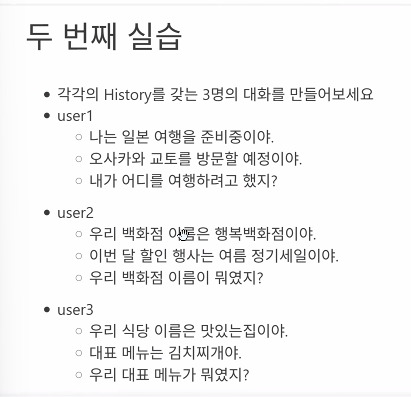

In [64]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.prompts import MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory

# session별 ID
per1 = {'configurable':{'session_id':'user1'}} 
per2 = {'configurable':{'session_id':'user2'}} 
per3 = {'configurable':{'session_id':'user3'}} 
store = {} # key(session_id), value(InMemoryChatMessageHistory)

# ID별 MessageHistory 저장소
def get_memory(session_id):
    if session_id not in store:
        store[session_id] = InMemoryChatMessageHistory()
    return store[session_id]

# Prompt작성하면서 MessagesPlaceholder를 만듦
prompt = ChatPromptTemplate.from_messages([
    ('system','당신은 아주 사랑스럽고 밝고 친절한 한국어 챗봇이야'),
    MessagesPlaceholder('history2'), 
    ('user','{input}')    
])

# RunnableWithMessageHistory 만들기
chain = RunnableWithMessageHistory(
    prompt | llm,
    get_history,
    input_messages_key='input',
    history_messages_key='history2'
)

c:\AI_service\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [66]:
chain.invoke({'input':'안녕 챗봇!'},config=per1)
chain.invoke({'input':'나는 일본 여행을 준비중이야!'},config=per1)
chain.invoke({'input':'오사카와 교토를 방문할 예정이야!'},config=per1)

chain.invoke({'input':'내가 어디를 여행하려고 했지?'},config=per1).content

'당신은 오사카와 교토를 여행하려고 한다고 말씀하셨죠! 두 도시 모두 매력이 넘치는 곳이니 정말 기대되네요. 여행 준비에 대해 더 이야기할까요? 😊'

In [67]:
chain.invoke({'input':'안녕 챗봇!'},config=per2)
chain.invoke({'input':'우리 백화점 이름은 행복백화점이야.'},config=per2)
chain.invoke({'input':'이번 달 할인 행사는 여름 정기세일이야.'},config=per2)

chain.invoke({'input':'우리 백화점 이름이 뭐고, 이번달에 뭘 한다고했지?'},config=per2).content

'백화점 이름은 **행복백화점**이고, 이번 달에는 **여름 정기세일**을 한다고 하셨어요! 정말 흥미로운 소식이네요! 더 이야기하고 싶으신 부분이 있으면 말씀해 주세요! 😊'

In [68]:
chain.invoke({'input':'안녕 챗봇!'},config=per3)
chain.invoke({'input':'우리 식당 이름은 맛있는집이야.'},config=per3)
chain.invoke({'input':'대표 메뉴는 김치찌개야.'},config=per3)

chain.invoke({'input':'우리 대표 메뉴가 뭐였지?'},config=per3).content

'대표 메뉴는 김치찌개입니다! 정말 맛있겠네요. 김치찌개 외에도 다른 메뉴들이 있다면 함께 알려주시면 좋을 것 같아요! 😊'

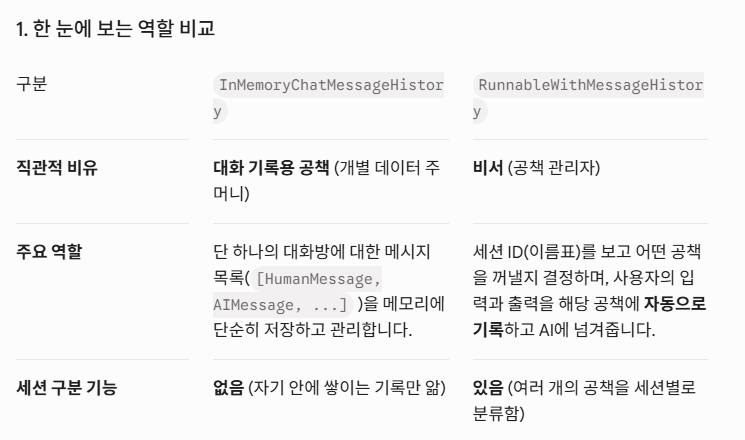

## 워크플로우로 이해하기
사용자가 chain.invoke({"input": "..."}, config=cfg1)를 호출했을 때의 내부 움직임입니다.

1) **RunnableWithMessageHistory** (비서)가 호출을 받음.

2) config에 적힌 session_id('user1')를 확인하고 **get_window_memory**('user1')을 실행함.

3) 연결된 창고에서 user1 전용 **InMemoryChatMessageHistory (공책)**을 꺼내옴.

4) 꺼내온 공책의 대화 기록을 프롬프트의 **MessagesPlaceholder** 자리에 자동으로 채워 넣음.

5) AI가 답변을 하면, 그 답변을 다시 user1 전용 **InMemoryChatMessageHistory (공책)에 자동으로 add_ai_message() 해줌**.

# WindowMemory : 최근 k개의  대화만 저장

- **최근 k개 턴만 유지: get_history 함수 내 슬라이싱으로 구현**

In [70]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.prompts import MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory

#세션별 ID
cfg1= {'configurable': {'session_id': 'user1'}}
cfg2= {'configurable': {'session_id': 'user2'}}

store={}    # key('session_id': 'user1') , 'memory': InMemoryChatMessageHistory()

def get_memory(session_id):
    if session_id not in store:
        store[session_id] = InMemoryChatMessageHistory()
    return store[session_id]

def get_window_memory(session_id):
    h = get_memory(session_id)
    h.messages = h.messages[-2:]
    return h

prompt = ChatPromptTemplate.from_messages([
    ('system', '당신은 친절한 챗봇이야'),
    MessagesPlaceholder('history1'),
    ('user', '{input}')
])

chain = RunnableWithMessageHistory(
    prompt | llm,
    get_window_memory,
    input_messages_key='input',
    history_messages_key='history1'
)

c:\AI_service\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


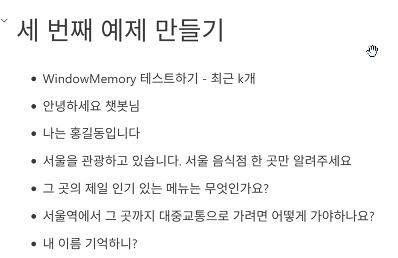

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

per1 = {'configurable': {'session_id': 'user1'}} 
per2 = {'configurable': {'session_id': 'user2'}} 
per3 = {'configurable': {'session_id': 'user3'}} 

store = {}  # key: session_id, value: InMemoryChatMessageHistory()

def get_memory(session_id):
    if session_id not in store:
        store[session_id] = InMemoryChatMessageHistory()
    return store[session_id]

def get_window_memory(session_id):
    h = get_memory(session_id)
    h.messages = h.messages[-10:]
    
    return h

prompt = ChatPromptTemplate.from_messages([
    ('system', '당신은 아주 사랑스럽고 밝고 친절한 한국어 챗봇이야'),
    MessagesPlaceholder('history3'), 
    ('user', '{input}')    
])

chain = RunnableWithMessageHistory(
    prompt | llm,
    get_window_memory, 
    input_messages_key='input',
    history_messages_key='history3'
)

chain.invoke({'input': '안녕 챗봇!'}, config=per1)
chain.invoke({'input': '내 이름은 박혜준이야!!'}, config=per1)
chain.invoke({'input': ' 서울을 관광하고 있습니다. 서울 음식점 한 곳만 알려주세요!'}, config=per1)
chain.invoke({'input': '그 곳의 제일 인기 있는 메뉴는 무엇인가요?'}, config=per1)
chain.invoke({'input': '서울역에서 그 곳까지 대중교통으로 가려면 어떻게 가야하나요?'}, config=per1)

# 마지막 질문 던지기
result = chain.invoke({'input': '내이름이 뭐라고 했지?'}, config=per1)
print(result.content)

c:\AI_service\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


당신의 이름은 박혜준님이에요! 다시 말씀해 주셔서 감사해요. 😊


# SummaryMemory : 대화 내용 요약

- **긴 대화 요약: get_history 함수 내 LLM으로 자동 요약**
- 아래 내용 요약

In [77]:
from langchain_openai import ChatOpenAI
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

per1 = {'configurable': {'session_id': 'user1'}} 
per2 = {'configurable': {'session_id': 'user2'}} 
per3 = {'configurable': {'session_id': 'user3'}} 

store = {}  # key: session_id, value: InMemoryChatMessageHistory()

def get_memory(session_id):
    if session_id not in store:
        store[session_id] = InMemoryChatMessageHistory()
    return store[session_id]

def get_summary_memory(session_id):
    h = get_memory(session_id)

    if len(h.messages) > 5:
        to_summary_messages = h.messages[:-4]
        context_text = "\n".join([f"{msg.type}: {msg.content}" for msg in to_summary_messages])
        
        summary_response = llm.invoke(f"다음 대화 내용을 한 줄로 요약해줘:\n{context_text}")
        summary_message = SystemMessage(content=f"[이전 대화 요약]: {summary_response.content}")
        
        h.messages = [summary_message] + h.messages[-4:]
    return h

prompt = ChatPromptTemplate.from_messages([
    ('system', '당신은 아주 사랑스럽고 밝고 친절한 한국어 챗봇이야'),
    MessagesPlaceholder('history4'), 
    ('user', '{input}')    
])

chain = RunnableWithMessageHistory(
    prompt | llm,
    get_summary_memory, 
    input_messages_key='input',
    history_messages_key='history4'
)

# 대화 실행 테스트
chain.invoke({'input': '안녕 챗봇!'}, config=per1)
chain.invoke({'input': '내 이름은 박혜준이야!!'}, config=per1)
chain.invoke({'input': '서울을 관광하고 있습니다. 서울 음식점 한 곳만 알려주세요!'}, config=per1)
chain.invoke({'input': '그 곳의 제일 인기 있는 메뉴는 무엇인가요?'}, config=per1)
chain.invoke({'input': '서울역에서 그 곳까지 대중교통으로 가려면 어떻게 가야하나요?'}, config=per1)

print("="*60)
print("[최종 저장된 메시지 구조 확인]")
print("="*60)
# 저장소 내부 데이터 타입과 컨텐트 출력
for msg in store["user1"].messages:
    print(f"타입: {type(msg).__name__} | 내용: {msg.content}")

c:\AI_service\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


[최종 저장된 메시지 구조 확인]
타입: SystemMessage | 내용: [이전 대화 요약]: 박혜준이라는 이름을 가진 사람이 챗봇과 인사를 나누고 이야기를 나누고 싶어 하는 대화입니다.
타입: HumanMessage | 내용: 서울을 관광하고 있습니다. 서울 음식점 한 곳만 알려주세요!
타입: AIMessage | 내용: 서울에서 꼭 가봐야 할 음식점 중 하나는 "광장시장"입니다! 여기서는 다양한 전통 한국 음식을 맛볼 수 있어요. 특히 "빈대떡"과 "막걸리"가 유명하답니다. 시장의 활기찬 분위기 속에서 여러 가지 음식을 즐길 수 있으니 꼭 방문해 보세요! 맛있게 드세요! 🍽️😊
타입: HumanMessage | 내용: 그 곳의 제일 인기 있는 메뉴는 무엇인가요?
타입: AIMessage | 내용: 광장시장에서 가장 인기 있는 메뉴는 "빈대떡"과 "육회"입니다! 빈대떡은 전통적인 전으로, 바삭하게 구워지며 다양한 재료가 들어가서 맛이 정말 좋답니다. 육회는 신선한 소고기를 사용한 요리로, 고소하고 깔끔한 맛이 매력적이에요. 또, 시장에는 다양한 다른 음식을 즐길 수 있으니 여러 가지 시도해보는 것도 좋답니다! 😊 맛있는 경험이 되길 바랄게요!
타입: HumanMessage | 내용: 서울역에서 그 곳까지 대중교통으로 가려면 어떻게 가야하나요?
타입: AIMessage | 내용: 서울역에서 광장시장까지 대중교통으로 가는 방법은 다음과 같아요:

1. **지하철 이용하기**:
   - 서울역에서 4호선(파란색) 지하철을 타고 **명동역**으로 갑니다.
   - 명동역에서 4호선에서 하차 후, **동대문역사문화공원역** 방향의 지하철을 타고 **회현역**에 하차합니다.
   - 회현역 7번 출구로 나가시면 광장시장이 도보로 가까워요.

2. **버스 이용하기**:
   - 서울역 근처에서 **지선버스 421번**이나 **일반버스 605**를 타고 **종로5가** 정류장에서 하차합니다.
   - 그곳에서 도보로 이동하면 광장시장에 도착할 수 있습니다.

두 방법

In [78]:
from openai import OpenAI
import os
client = OpenAI()
# 토큰 카운트 + 호출
messages = [{"role": "user", "content": "서울 광장시장에서 가장 맛있는 길거리 음식은 무엇인가요?"}]
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=messages,
    temperature=0
)
print(response.choices[0].message.content)
usage = response.usage
print(f"Total Tokens: {usage.total_tokens}")
print(f"Prompt Tokens: {usage.prompt_tokens}")
print(f"Completion Tokens: {usage.completion_tokens}")
print(f"Total Cost (USD): ${usage.total_tokens * 0.00015 / 1000:.6f}")  # gpt-4o-mini 요금

서울 광장시장에서 가장 인기 있는 길거리 음식으로는 다음과 같은 것들이 있습니다:

1. **떡볶이**: 매콤한 고추장 소스에 쌀떡과 어묵, 채소가 들어간 인기 있는 간식입니다.
2. **순대**: 돼지의 창자에 찹쌀, 당면, 채소 등을 넣어 만든 음식으로, 보통 간장이나 고추장 소스와 함께 먹습니다.
3. **호떡**: 달콤한 시럽이 들어간 팬케이크로, 겨울철에 특히 인기가 많습니다.
4. **김밥**: 다양한 재료를 넣어 만든 김밥은 간편하게 먹을 수 있는 길거리 음식입니다.
5. **튀김**: 다양한 재료(예: 고구마, 오징어 등)를 튀겨서 제공하며, 바삭한 식감이 매력적입니다.

이 외에도 다양한 길거리 음식들이 있으니, 광장시장을 방문하시면 여러 가지를 맛볼 수 있습니다!
Total Tokens: 258
Prompt Tokens: 23
Completion Tokens: 235
Total Cost (USD): $0.000039


# LCEL
- **정의**: 
LCEL은 LangChain Expression Language의 약자로 **체인을 함수형 방식으로 구성하는 표준 방법**
- **핵심 메커니즘** 
모든 컴포넌트를 `Runnable` 인터페이스로 통일하여, 파이프 연산자 (`|`)를 기반으로 직관적으로 연결한다.
- **목적** LLM 애플리케이션의 모듈화, 확장성, 그리고 유지보수 편의성을 극대화한다.

In [83]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = PromptTemplate.from_template("{city}의 랜드마크는?")
parser = StrOutputParser()

chain = prompt | llm | parser
ret = chain.invoke({'city':'호주 골드코스트'})
print(ret)

호주 골드코스트의 주요 랜드마크에는 다음과 같은 곳들이 있습니다:

1. **서퍼스 파라다이스 (Surfers Paradise)** - 골드코스트의 상징적인 해변과 높은 아파트 건물들이 있는 지역으로, 관광객들에게 매우 인기 있습니다.

2. **드림월드 (Dreamworld)** - 호주의 가장 큰 테마파크 중 하나로, 다양한 놀이기구와 동물들이 있어 가족 단위 방문객들에게 인기가 많습니다.

3. **시월드 (Sea World)** - 해양 생물을 주제로 한 테마파크로, 공연과 다양한 해양 생물을 관람할 수 있는 장소입니다.

4. **무비 월드 (Movie World)** - 영화와 할리우드 테마의 놀이공원으로, 다양한 영화 관련 어트랙션과 쇼가 열립니다.

5. **골드코스트 해양 박물관 (Gold Coast Marine Museum)** - 해양 생물과 관련된 전시물이 있는 박물관입니다.

6. **버스타운 (Burleigh Heads)** - 아름다운 자연경관과 해양 스포츠를 즐길 수 있는 장소로, 특히 서핑 명소로 유명합니다.

이 외에도 골드코스트에는 아름다운 해변과 자연 경관, 다양한 레스토랑과 쇼핑 장소들이 많아 많은 관광객들이 방문하는 매력적인 지역입니다.


### ==============================================================================================

# **Runnable: LCEL의 모든 체인 요소는 Runnable이다**

## RunnableLambda

- **RunnableLambda**는 LangChain에서 파이썬 함수를 래핑(wrapping)해서, 체인(Chain)이나 LCEL 파이프라인에서 재사용 가능한 "실행 가능한 객체(Runnable)"로 만들어주는 도구이다. 
즉, 일반 함수를 체인에 쉽게 끼워 넣을 수 있다.
- 실제 프로젝트를 개발하다 보면 다음과 같은 **커스텀 데이터 가공**이 필요하다.
    - LLM에 입력하기 전에 텍스트 전처리 (공백 제거, 특정 단어 필터링 등)
    - 출력 파서가 뱉어낸 데이터를 최종 서비스 형태(JSON, HTML 등)로 재가공
    - 외부 API 호출 또는 데이터베이스(DB) 조회 결과를 중간에 삽입
    
    이때 일반 파이썬 함수는 `|` 연산자를 직접 사용할 수 없으므로, 이를 **LangChain 규격에 맞는 `Runnable`로 변환해 주는 어댑터 역할**을 한다.
    
- 즉, LCEL의 핵심은 **여러 Runnable을 파이프라인으로 연결**하는 것
- LCEL에서 프롬프트, LLM, 파서, 사용자 함수 등 파이프(|)로 연결되는 모든 단계는 **내부적으로 Runnable 객체**.
- **RunnableLambda**를 활용하면, 체인 중간에 원하는 파이썬 함수를 자유롭게 삽입해 데이터 흐름을 제어할 수 있다

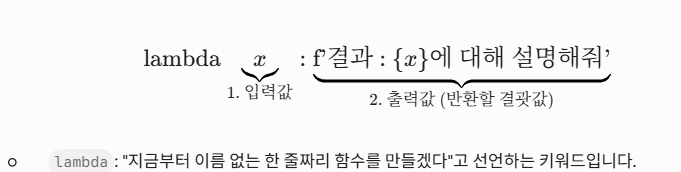

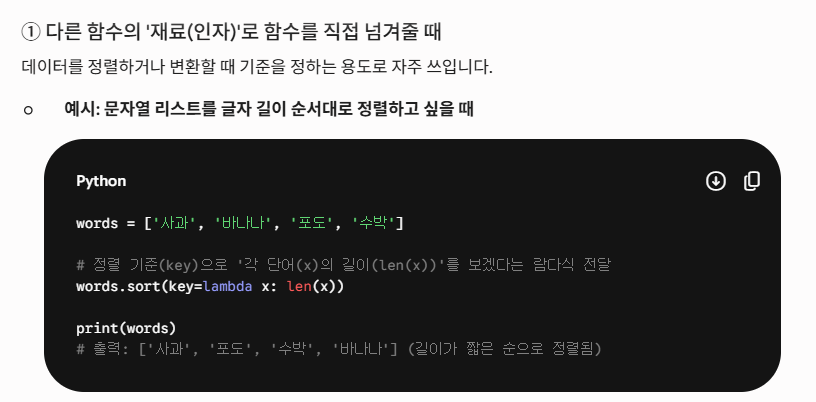

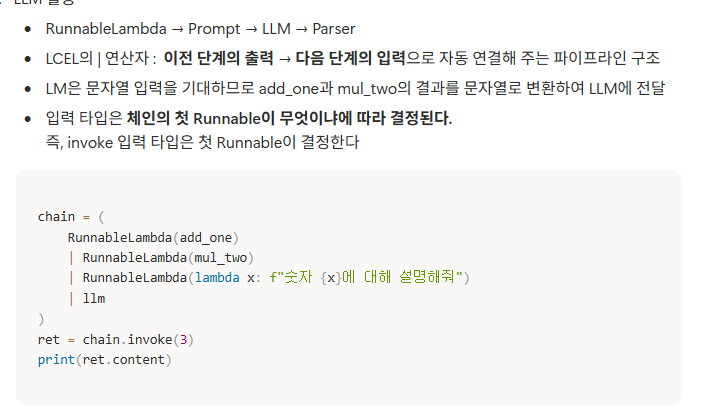

In [87]:
from langchain_core.runnables import RunnableLambda

def add(a):
    return a + 10

def mul(a):
    return a * 10

chain = RunnableLambda(add) | RunnableLambda(mul) | RunnableLambda(lambda x: f'결과 : {x}에 대해 설명해줘') | llm
ret = chain.invoke(5)
print(ret)

content='"결과: 150"이라는 문구는 맥락에 따라 다르게 해석될 수 있습니다. 일반적으로 숫자 "150"은 여러 가지 상황에서 결과로 나타날 수 있는데, 여기에는 다음과 같은 예시들이 포함될 수 있습니다:\n\n1. **수학적 계산 결과**: 어떤 수식이나 계산이 수행된 후 그 결과가 150일 수 있습니다.\n   - 예: \\( 100 + 50 = 150 \\)\n\n2. **통계적 데이터**: 설문조사, 실험 등의 결과로 150이라는 수치가 나올 수 있습니다. 예를 들어, 어떤 그룹에서 150명이 응답했거나, 특정한 사건의 수치적 결과가 150인 경우.\n\n3. **점수**: 시험, 게임 또는 평가에서 점수가 150인 경우, 이는 해당 결과를 나타내는 중요 지표가 될 수 있습니다.\n\n4. **비교적 수치**: 예를 들어, 한 현상이 다른 현상과 비교했을 때 150의 값이 매우 의미 있는 데이터를 제공할 수 있습니다.\n\n이와 같은 다양한 의미를 지닌 숫자 "150"에 대한 구체적인 내용이나 맥락을 제공해 주시면, 더 깊이 있는 설명이나 정보를 제공해 드릴 수 있습니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 275, 'prompt_tokens': 17, 'total_tokens': 292, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp

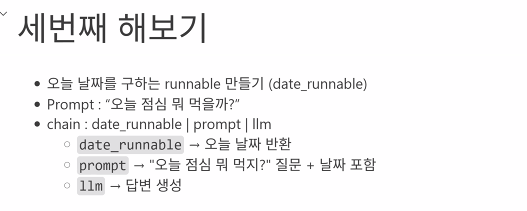

- **RunnableLambda**는 : <br>
: 랭체인(LangChain)에서 "일반 파이썬 함수를 랭체인 전용 파이프라인(| 연산자)에서 사용할 수 있는 부품으로 변환해 주는 변형기

In [ ]:
# geminai랑 내가 해본 것

from langchain_core.runnables import RunnableLambda
from datetime import datetime

def date_runnable(day):
    date_obj = datetime.strptime(str(day), "%Y%m%d")
    return date_obj.strftime("%Y-%m-%d")

prompt = PromptTemplate.from_template('오늘은 {day}이야. 오늘 점심 뭐먹을 지 시기에 맞게 추천해줘')
parser = StrOutputParser()

chain = (
    RunnableLambda(date_runnable) 
    | RunnableLambda(lambda x: {'day': x}) 
    | prompt 
    | llm 
    | parser
)
ret = chain.invoke('20260618')
print(ret)

2026년 6월 18일은 여름이 시작되는 시기이므로, 가벼우면서도 시원하게 즐길 수 있는 음식을 추천드립니다. 다음과 같은 점심 메뉴를 고려해 보세요:

1. **냉면**: 차가운 육수에 면과 다양한 야채를 곁들인 냉면은 더운 날씨에 적합한 시원한 한 끼입니다.

2. **샐러드 볼**: 신선한 채소와 과일, 훈제 연어나 닭가슴살, 드레싱을 더한 샐러드는 건강하면서도 부담 없이 즐길 수 있습니다.

3. **회덥밥**: 신선한 해산물과 고소한 밥, 다양한 나물과 함께 먹는 회덥밥은 여름철에 잘 어울리는 시원한 느낌의 음식입니다.

4. **토마토 파스타**: 상큼한 토마토 소스를 곁들인 파스타는 여름철에 잘 어울리며, 가벼운 느낌으로 즐기기 좋습니다.

5. **오이 냉국**: 상큼한 오이를 사용한 냉국은 입맛을 돋우고, 더위에 시원하게 먹기 좋은 메뉴입니다.

일기와 기호에 맞는 음식을 선택해 즐거운 점심시간 보내세요!


In [99]:
# 강사님이 해주신 코드
from langchain_core.runnables import RunnableLambda
from datetime import datetime

date_runnable = RunnableLambda(lambda _:{
    'today' : datetime.now().strftime('%Y-%m-%d'),
    'query':'오늘 점심 뭐먹을 지 시기에 맞게 추천해줘'
})

prompt = ChatPromptTemplate.from_messages([
    ('system','당신은 친절한 챗봇입니다. 반드시 날짜를 출력해주세요.'),
    ('user','오늘은 {today}입니다. {query}!')
])

parser = StrOutputParser()

chain = (
    date_runnable
    | prompt 
    | llm 
    | parser
)
ret = chain.invoke({})
print(ret)

오늘은 2026년 6월 18일입니다. 더운 여름날인 만큼, 시원한 냉면이나 과일 샐러드를 추천해 드립니다. 또는 가벼운 샌드위치와 함께 아이스티 한 잔도 좋겠네요. 맛있게 드세요!


## RunnableParallel

- LCEL(LangChain Expression Language)에서 **여러 작업을 동시에(병렬로) 실행**하고, 그 결과들을 하나의 딕셔너리로 모아주는 컴포넌트
  
- 지금까지는 체인들(`prompt | llm | parser`)은 한 단계가 끝나야 다음 단계로 넘어가는 **순차적** 구조였다면, <br>`RunnableParallel`은 같은 입력을 여러 체인에 동시에 흘려보내서, 서로 독립적인 여러 작업을 한 번에 처리하고 싶을 때 사용한다.

In [103]:
from langchain_core.runnables import RunnableParallel
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
parser = StrOutputParser()

# a : {topic}의 장점
# b : {topic}의 단점

a = PromptTemplate.from_template('{topic}의 장점에 대해 설명해줘.')
a_chain = a | llm | parser 
b = PromptTemplate.from_template('{topic}의 단점에 대해 설명해줘.')
b_chain = b | llm | parser

parallel_chain = RunnableParallel(a=a_chain, b=b_chain)
ret = parallel_chain.invoke({'topic':'월드컵'})
print(ret)


{'a': '월드컵은 세계에서 가장 큰 축구 대회 중 하나로, 여러 가지 장점이 있습니다. 다음은 월드컵의 주요 장점들입니다:\n\n1. **국제적 화합**: 월드컵은 다양한 국가와 문화가 모여 하나의 축제를 만들어내는 기회입니다. 각국의 팬들이 경기를 통해 서로 소통하고 이해할 수 있는 기회를 제공합니다.\n\n2. **스포츠 발전**: 월드컵은 전 세계적으로 축구에 대한 관심을 높이고, 축구 인프라와 유소년 육성을 촉진하는 데 기여합니다. 많은 나라들이 월드컵을 준비하면서 축구의 수준이 향상됩니다.\n\n3. **경제적 효과**: 대회가 개최되는 나라는 많은 관광객을 유치하게 되며, 이는 경제 활성화에 기여합니다. 호텔, 음식점, 교통 등 다양한 산업이 혜택을 받습니다.\n\n4. **문화 교류**: 월드컵은 각국의 문화와 전통을 소개할 수 있는 기회를 제공합니다. 다양한 음식을 즐기고, 각국의 팬들과의 교류를 통해 문화적 이해가 증진됩니다.\n\n5. **사회적 연대감**: 월드컵은 국가적 자부심을 고취시키고, 국민들이 팀을 응원하며 하나로 뭉치는 계기가 됩니다. 이는 사회적 연대감을 강화하는 데 큰 도움을 줍니다.\n\n6. **스타 출현**: 월드컵을 통해 많은 축구 선수가 전 세계적으로 주목받고, 그들의 경기가 팬들에게 감동과 희망을 줍니다. 이는 젊은 선수들에게도 큰 영감을 줍니다.\n\n7. **긴장감과 흥미**: 세계적인 무대에서의 경쟁은 극적인 순간과 놀라운 경기를 제공합니다. 이는 팬들에게 큰 흥미와 긴장감을 안겨주며, 이로 인해 축구에 대한 열정이 더욱 강화됩니다.\n\n이처럼 월드컵은 단순한 스포츠 행사 이상의 의미를 갖고 있으며, 전 세계적으로 긍정적인 영향을 미치는 중요한 이벤트입니다.', 'b': '월드컵은 세계적인 축구 대회로 많은 사람들에게 즐거움을 주지만, 몇 가지 단점도 있습니다. 다음은 그 주요 단점들입니다.\n\n1. **과도한 상업화**: 월드컵은 큰 규모의 상업적 이벤트로, 광고와 스폰서십이 많습니다. 이로 인해 경기

# LangChain Caching

- LangChain Caching은 동일한 LLM 요청이 반복될 경우, 이전 응답을 저장해두었다가 재사용하는 기능이다.
  
  
- 동일한 프롬프트나 메시지에 대한 응답을 **OpenAI 등에 다시 요청하지 않고 캐시에서 꺼내 사용**
- 캐시는 LLM 호출 레벨에서 자동으로 작동하며, 한 번 설정하면 **LangChain 체인 전체에 적용**된다.

<장점>  
- OpenAI API 호출 횟수를 줄이고
- 비용을 절감하며
- 반복 실험 및 프롬프트 튜닝을 효율적으로 수행할 수 있다.

<특징>
- 프로그램 종료 시 데이터 삭제
- 서버 재시작시 캐시 초기화
- 다중 서버 환경에서 공유 불가(각 서버마다 다른 메모리)
    - 실무에서는 Redis, SQLite, Upstash등 외부 캐시를 사용

In [110]:
import time
from langchain_core.globals import set_llm_cache
from langchain_community.cache import InMemoryCache
from langchain_core.prompts import PromptTemplate

set_llm_cache(InMemoryCache())

prompt = PromptTemplate.from_template('세상에서 가장 귀엽고 깜찍한 동물은 무엇인가요? 이유도 하나 설명해주세요')
chain = prompt | llm

# --- [첫 번째 호출]  ---
start_time = time.time()
ret1 = chain.invoke({})
print("첫 번째 답변:", ret1.content)
print(f"첫 번째 소요 시간: {time.time() - start_time:.2f}초\n")

# --- [두 번째 호출] 저장된 캐시에서 바로 꺼내옴 ---
start_time = time.time()
ret2 = chain.invoke({})
print("두 번째 답변:", ret2.content)
print(f"두 번째 소요 시간: {time.time() - start_time:.2f}초")

C:\Users\KDA 25\AppData\Local\Temp\ipykernel_33104\280579875.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.cache import InMemoryCache


첫 번째 답변: 세상에서 가장 귀엽고 깜찍한 동물 중 하나는 판다입니다. 이유는 판다의 둥글둥글한 얼굴과 큰 눈, 그리고 땡글땡글한 몸매가 매우 사랑스럽기 때문입니다. 또한, 그들의 유순한 성격과 나무에서 느릿느릿하게 움직이는 모습도 사람들에게 큰 귀여움을 주며, 자연에서의 평화로운 모습을 보고 있으면 저절로 미소가 지어집니다. 판다는 귀여움을 떠나서 멸종 위기종이라는 점에서도 많은 사람들의 사랑과 보호를 받고 있습니다.
첫 번째 소요 시간: 3.68초

두 번째 답변: 세상에서 가장 귀엽고 깜찍한 동물 중 하나는 판다입니다. 이유는 판다의 둥글둥글한 얼굴과 큰 눈, 그리고 땡글땡글한 몸매가 매우 사랑스럽기 때문입니다. 또한, 그들의 유순한 성격과 나무에서 느릿느릿하게 움직이는 모습도 사람들에게 큰 귀여움을 주며, 자연에서의 평화로운 모습을 보고 있으면 저절로 미소가 지어집니다. 판다는 귀여움을 떠나서 멸종 위기종이라는 점에서도 많은 사람들의 사랑과 보호를 받고 있습니다.
두 번째 소요 시간: 0.01초


# Redis연결

In [121]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)
redis_host = os.getenv("REDIS_HOST")
redis_password = os.getenv("REDIS_PASSWORD")
redis_port = os.getenv("REDIS_PORT")

In [122]:
from langchain_core.globals import set_llm_cache
from langchain_community.cache import RedisCache
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate
import redis


redis_client = redis.Redis(
    host=redis_host,
    port=redis_port,
    password=redis_password,
    db=0  #Redis는 하나의 서버 안에 여러 개의 논리적 DB를 가짐, db=0은 기본 DB를 사용하겠다는 의미
)


# 메모리 기반 캐시 활성화
set_llm_cache(RedisCache(redis_client))

#서울에서 가장 맛있는 길거리 음식 5개를 소개해 주세요
#서울에서 가장 맛있는 길거리 음식 10개를 소개해 주세요

prompt = ChatPromptTemplate.from_template(
  "서울 남대문시장에서 가장 맛있는 길거리 음식 5개를 소개해 주세요?")

chain = prompt | llm

In [123]:
%%time

response = chain.invoke({})
print(response)

content='서울 남대문시장에서 맛있는 길거리 음식으로는 다음과 같은 것들이 있습니다:\n\n1. **떡볶이**: 매콤하고 달콤한 소스로 버무려진 떡과 어묵이 조화를 이루는 인기 있는 길거리 음식입니다. 다양한 식당이 있지만, 소스의 맛과 질감이 매력적인 곳을 찾아보세요.\n\n2. **호떡**: 달콤한 꿀과 견과류를 속에 넣어 구운 전통적인 한국식 팬케이크입니다. 따뜻하고 바삭한 겉과 달콤한 속이 어우러져 간단하면서도 맛있는 간식으로 인기가 높습니다.\n\n3. **김밥**: 다양한 재료를 넣어 만든 김밥은 손쉽게 먹을 수 있는 간편식입니다. 남대문시장에서는 여러 가지 종류의 김밥을 판매하므로, 좋아하는 재료를 선택해 즐길 수 있습니다.\n\n4. **순대**: 찹쌀, 당면, 야채 등을 소시지 모양으로 쪄서 만든 음식으로, 간단한 소스와 함께 먹으면 맛있습니다. 남대문시장에서는 오랜 역사를 가진 순대 전문점들도 많습니다.\n\n5. **튀김**: 다양한 해산물이나 채소를 바삭하게 튀겨낸 음식으로, 고소하고 crunchy한 맛이 일품입니다. 다양한 종류의 튀김을 한 자리에서 즐길 수 있는 것이 남대문시장의 매력 중 하나입니다.\n\n이 외에도 남대문시장에는 다양한 길거리 음식이 많으니, 발걸음을 옮기다 보면 새로운 맛을 발견할 수 있을 것입니다!' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 372, 'prompt_tokens': 27, 'total_tokens': 399, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, '

# Output parser

- **Output Parser**는 LLM이 생성한 텍스트를 **프로그램이 쓰기 좋은 구조(리스트/딕트/모델 등)**로 변환하는 컴포넌트.
  
- 과거에는 “모델이 자연어만 잘 뱉는다”가 전제라서 Output Parser가 구조화 출력의 대표 해법이었지만,<br>
  
**현재는 많은 LLM이 구조화 출력을 자체 지원**(예: JSON schema/툴 호출/structured output)하므로, <br>
가능한 경우 **모델의 네이티브 구조화 기능을 우선** 쓰고, 그게 어렵거나(모델 미지원/통합 제약) **추가 검증·후처리**가 필요할 때 Output Parser를 쓰는 식이 권장된다.

In [125]:
from pydantic import BaseModel, Field

from langchain_core.output_parsers import PydanticOutputParser
class Person(BaseModel):
    name : str = Field(description='사람의 이름')
    age : int = Field(description='사람의 나이')

output = PydanticOutputParser(pydantic_object=Person)

prompt = PromptTemplate.from_template(
    ''' 다음 문장에서 이름과 나이를 추출하세요
    문장 : {text}
    {format_instructions} 
    ''').partial(format_instructions=output.get_format_instructions())


chain = prompt | llm | output
ret = chain.invoke({'text' : '박혜민은 32살 입니다.'})
print(ret)

name='박혜민' age=32


# Decorater : @dataclass
- : 기존 함수를 수정하지 않고, 새로운 기능을 추가(장식)해 주는 도구

- 코드의 중복을 줄이고, 여러 함수에 공통적으로 적용해야 하는 기능(**예: 실행 시간 측정, 로그인 여부 확인, 로그 기록 등**)이 있을 때 주로 사용

만약 내가 만든 10개의 함수가 각각 실행되는 데 시간이 얼마나 걸리는지 측정
  
: 데코레이터가 없다면 10개 함수 모두의 시작과 끝에 일일이 시간 측정 코드를 적어야 합니다.

❌ 데코레이터가 없는 경우 (비효율적인 중복)

In [126]:
import time

def sub_func1():
    start = time.time()  # 중복 코드 1
    print("핵심 로직 1 실행")
    print(f"소요시간: {time.time() - start}")  # 중복 코드 2

def sub_func2():
    start = time.time()  # 중복 코드 1
    print("핵심 로직 2 실행")
    print(f"소요시간: {time.time() - start}")  # 중복 코드 2

⭕ 데코레이터를 쓰는 경우 (깔끔한 분리)
  
시간 측정 로직을 딱 한 번만 따로 빼서 데코레이터로 만들고, 적용하고 싶은 함수 위에 @데코레이터_이름만 붙여주면 끝납니다.

In [ ]:
import time

# 1. 데코레이터 함수 정의 (함수를 인자로 받음)
def time_checker(func):
    def wrapper(): # 즉, 원래 기능은 그대로 유지하면서 겉에 래퍼(Wrapper, 포장지)를 한 겹 씌워서 기능을 확장
        start = time.time()
        func()  # 원래 함수 실행
        print(f"소요시간: {time.time() - start:.4f}초")
    return wrapper

# 2. @ 기호를 사용해 장식하기
@time_checker
def sub_func1():
    print("핵심 로직 1 실행")

@time_checker
def sub_func2():
    print("핵심 로직 2 실행")

# 실행해보기
sub_func1()

문법적 비밀 (@ 기호의 정체)
  
: 함수 위에 붙은 @time_checker는 파이썬이 쓰기 편하게 제공하는 문법적 설탕일 뿐입니다. 실제 내부적으로는 다음과 같이 작동합니다.

- @time_checker 문법은 사실 아래 코드와 완벽히 같습니다.<br>
sub_func1 = time_checker(sub_func1)

💡 **요약**<br>
데코레이터는 함수를 포장하는 또 다른 함수입니다.
  
핵심 로직과 부가 기능(로그, 보안 체크, 캐싱 등)을 철저히 분리하여 코드의 재사용성을 극대화할 때 사용합니다.

In [130]:
from langchain_openai import ChatOpenAI                  
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage           

# ========================================================
# 1. 데코레이터 실습 파트 (상단부 오타 수정)
# ========================================================
def myDeco(func):
    def wrapper():
        print('함수 시작')
        func()
        print('함수 종료')
    return wrapper

# @tools.decorator(myDeco) 대신 파이썬 표준 방식인 @myDeco로 통일합니다.
@myDeco
def hello():
    print('Hello, World!')

@myDeco
def hello2():
    print('안녕하세요')

hello()
hello2()

# ========================================================
# 2. 랭체인 툴 바인딩 파트
# ========================================================
@tool
def add(x: int, y: int) -> int:
    ''' 두 숫자를 더하는 함수입니다.'''
    return x + y

# default_model 대신 실제 OpenAI 모델명 문자열을 기입합니다.
llm = ChatOpenAI(model="gpt-4o-mini") 
llm_with_tool = llm.bind_tools([add])

query = '5와 7을 더한 결과는 무엇인가요?'

# [수정] HumanMessages -> HumanMessage 객체로 변경
res1 = llm_with_tool.invoke([HumanMessage(content=query)])
print(res1.tool_calls)

함수 시작
Hello, World!
함수 종료
함수 시작
안녕하세요
함수 종료
[{'name': 'add', 'args': {'x': 5, 'y': 7}, 'id': 'call_YLLioDDHeDK6AHdMtWzlnrVW', 'type': 'tool_call'}]


**랭체인(LangChain)에서 AI 모델에게 "계산기", "날짜 확인", "웹 검색" 같은 무기(기능)를 쥐여줄 때 @tool이라는 데코레이터를 사용**

1. 왜 @tool 데코레이터를 쓸까? (존재 이유)
AI 모델(예: GPT)은 기본적으로 텍스트를 읽고 쓰는 기계일 뿐, 파이썬 코드를 스스로 실행할 능력이 없습니다.<br>
  
우리가 만든 파이썬 함수(예: "두 수를 더하는 함수")를 AI에게 선물하고 싶다면, AI가 읽을 수 있는 형태로 함수를 번역해 주어야 합니다. AI는 텍스트만 읽을 수 있으므로,<br>
 "이 함수의 이름은 무엇이고, 어떤 매개변수를 받으며, 무슨 일을 하는지" 적힌 설명서(JSON 구조)가 필요합니다.<br>
   
내가 만든 일반 함수 위에 @tool만 얹어주면, 랭체인이 그 함수를 뜯어보고 AI가 읽을 수 있는 설명서를 자동으로 생성해 줍니다.<br>



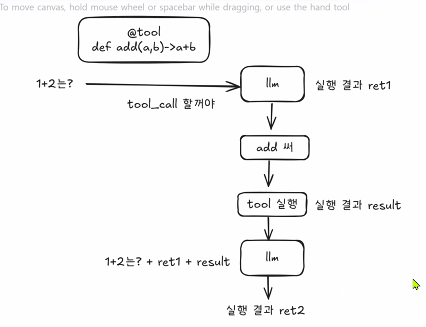

In [ ]:
from langchain_core.tools import tool

# @tool 데코레이터를 붙이는 순간, 이 함수는 랭체인 전용 부품으로 대개조됩니다.
@tool
def add_numbers(a: int, b: int) -> int:
    """두 개의 정수를 더해주는 함수입니다."""  # <--- 이 주석(Docstring)이 엄청 중요합니다!
    return a + b

**1. 원래 사용하던 방식 (기억하시는 복잡한 프로세스)**

@tool 없이 순수 API 방식으로 add_numbers라는 함수를 명세서로 만들어 제공하려면 아래와 같이 코드를 짜야 했습니다.

In [ ]:
# 1. 사용자 정의 함수 만들기
def add_numbers(a, b):
    return a + b

# 2. 툴 속성 정의 및 명세서(JSON Schema) 직접 작성 (1차 호출용)
add_numbers_spec = {
    "type": "function",
    "function": {
        "name": "add_numbers",
        "description": "두 개의 정수를 더해주는 함수입니다.",
        "parameters": {
            "type": "object",
            "properties": {
                "a": {"type": "integer", "description": "첫 번째 숫자"},
                "b": {"type": "integer", "description": "두 번째 숫자"}
            },
            "required": ["a", "b"]
        }
    }
}

# 3. 툴 맵(Tool Map) 만들기 (AI가 이름을 뱉었을 때 실제 함수와 매핑할 주머니)
tool_map = {
    "add_numbers": add_numbers
}

# 4. 1차 호출할 때 명세서 제공하기
# response = openai.chat.completions.create(model="gpt-4o", messages=..., tools=[add_numbers_spec])

# DAY 05 시작

**@tool 데코레이터로 간소화된 방식**
  
랭체인의 @tool은 파이썬의 타입 힌트(a: int)와 함수 주석(Docstring)을 실시간으로 추적하여, 위의 복잡한 2번(명세서 제작)과 3번(툴 맵 등록) 과정을 내부적으로 자동 처리해 버립니다.

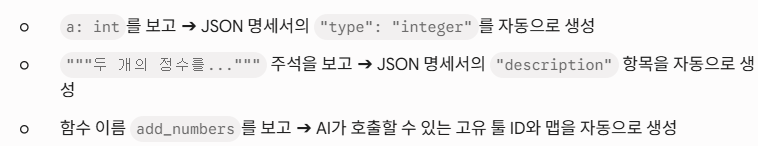

In [155]:
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, ToolMessage


@tool # tool 데코레이터 -> 랭체인에서 인식함.
def add(x: int, y: int) -> int:
    ''' 두 숫자를 더하는 함수입니다.'''
    return x + y

@tool
def strlen(x:str) -> int:
    '''문자열의 길이를 반환하는 함수입니다'''
    return len(x)


tools = [add, strlen]   # 툴 여러개 쓸수있게 목록생성
tools_dict = { tool.name : tool for tool in tools} # 툴(함수)이름 : 문자열 & 툴(함수) # {'add' : add }

llm = ChatOpenAI(model=default_model) 
llm_with_tools = llm.bind_tools(tools) # add라는 tool을 사용할수 있는 llm객체


query = "'무궁화 꽃이 피었습니다'라는 문자열의 길이를 구해줘 그리고 그 결과에 3을 더해줘" # 툴을 한개밖에 사용못하는데...! 오류남
# query = '5와 7을 더해줘'
# query = '바나나는 무슨색이니?'




# ----------------tool 사용시 llm 2번호출! ---------------
#1차 llm 호출 - tool 사용 여부 판단
ret1 = llm_with_tools.invoke(query)
# 사용할거면 tool_calling이라는 객체가 채워져서 반환/아니면 비어있음. -> 존재하면 해당 tool을 실행시켜야함.
print(ret1.tool_calls)

if ret1.tool_calls :
    #tool을 호출 결과 result로 반환
    call = ret1.tool_calls[0]
    result = tools_dict[call['name']].invoke(call['args']) # add(5,7) 함수 실행한걸 result에 저장

#2차 호출
    # 함수실행 결과와함께! 기존 쿼리랑 같이 다시 llm에 전달

    messages = [('user', query), # user의 질문
                ret1, # 1차 호출의 결과값(ret(tool_calls))
                ToolMessage(tool_call_id=call['id'], content=result)] #ToolMessage도 전달가능(call_id,content라는 매개변수 필요)
    ret2 = llm_with_tools.invoke(messages)
    print(ret2.content)
    

else:
    print(ret1.content)

c:\AI_service\.venv\Lib\site-packages\langchain_community\cache.py:413: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  generations.append(loads(cast(str, text)))


[{'name': 'strlen', 'args': {'x': '무궁화 꽃이 피었습니다'}, 'id': 'call_BIqCGokl2YiKQB0cawlV1Gic', 'type': 'tool_call'}, {'name': 'add', 'args': {'x': 8, 'y': 3}, 'id': 'call_sIttEzVDaf5HmYCjfozYKBFJ', 'type': 'tool_call'}]


BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_sIttEzVDaf5HmYCjfozYKBFJ", 'type': 'invalid_request_error', 'param': 'messages', 'code': None}}

### 툴을 한번에 여러개 사용하고싶을때!

In [ ]:
# tool 한 개 정의
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
load_dotenv()
# Tool 정의
#@tool은 일반 Python 함수를 Agent가 사용할 수 있는 Tool로 등록해 주는 데코레이터.
#Agent는 함수명, 타입 힌트, Docstring을 읽어서 언제 이 Tool을 사용할지 판단한다.



@tool
def add(a: int, b: int) -> int:
    """두 숫자를 더합니다."""
    return a + b
@tool
def get_word_length(word: str) -> int:
    """단어나 문장의 정확한 글자 수(길이)를 계산할 때 사용합니다."""
    return len(word)



# LLM 생성
llm = ChatOpenAI(model=default_model)  #gpt-4o
tools=[add, get_word_length]
tools_dict = { t.name: t for t in tools }


# Tool 연결
llm_with_tool = llm.bind_tools(tools)


# 질문
# query = '5와 7을 더하기'
# query = "'만나서 반갑습니다'는 글자 수가 몇 개인지 알려줘"
query = "'만나서 반갑습니다'는 글자 수가 몇 개인지 알려주고, 그 결과에 5를 더해줘" # 오류 남

messages = [('user', query)]

# ==================================이 부분이 포인트! 
for _ in range(10):
    res = llm_with_tool.invoke(messages)
    messages.append(res) 
    if not res.tool_calls:
        print(res.content)
        break
    
    for call in res.tool_calls:
        result = tools_dict[call['name']].invoke(call['args'])
        print(f"\nTool '{call['name']}' 실행 결과: {result}")
        messages.append(ToolMessage(tool_call_id=call['id'], content=str(result)))    
        print(messages)
print(res.content)

c:\AI_service\.venv\Lib\site-packages\langchain_community\cache.py:413: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  generations.append(loads(cast(str, text)))



Tool 'get_word_length' 실행 결과: 9

Tool 'add' 실행 결과: 5
'만나서 반갑습니다'는 9글자입니다. 이 결과에 5를 더하면 14가 됩니다.
'만나서 반갑습니다'는 9글자입니다. 이 결과에 5를 더하면 14가 됩니다.


In [164]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import ToolMessage

search = TavilySearchResults(max_results=3)

@tool
def web_search(query: str) -> str:
    """웹 검색을 수행하는 도구입니다"""
    return search.run(query)

llm = ChatOpenAI(model=default_model)

tools = [add, get_word_length, web_search]
tools_dict = {t.name: t for t in tools}

llm_with_tool = llm.bind_tools(tools)

query = "서울과 도쿄의 날씨를 비교해줘"
messages = [('user', query)]

for _ in range(10):
    res = llm_with_tool.invoke(messages)
    messages.append(res)

    if not res.tool_calls:
        print(res.content)
        break

    for call in res.tool_calls:
        result = tools_dict[call["name"]].invoke(call["args"])
        messages.append(ToolMessage(tool_call_id=call["id"], content=str(result)))

c:\AI_service\.venv\Lib\site-packages\langchain_community\cache.py:413: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  generations.append(loads(cast(str, text)))


서울과 도쿄의 현재 날씨를 비교해 보겠습니다.

### 서울 날씨
- **현재 기온**: 25°C
- **상태**: 약간 흐리고 습함
- **습도**: 79%
- **바람**: 동북동, 9 km/h
- **예보**: 오후에 비가 올 가능성이 있음
- **강수 확률**: 79%
- **UV 지수**: 6.0 (해로움)

### 도쿄 날씨
- **현재 기온**: 22°C
- **상태**: 흐림
- **습도**: 78%
- **바람**: 남동, 12.6 km/h
- **예보**: 간헐적으로 흐림, 또는 비가 내릴 가능성이 있음
- **강수 확률**: 17%
- **UV 지수**: 낮음

### 요약 비교
- 서울은 기온이 25°C로 도쿄보다 더 덥고, 습도가 조금 더 높은 상태입니다.
- 두 도시 모두 흐린 날씨를 보이고 있으나, 서울은 오후에 비가 올 가능성이 더 높습니다.

이 정보를 바탕으로 계획을 세우시면 좋겠습니다!


## AGENT로 복잡한 tools대체하기

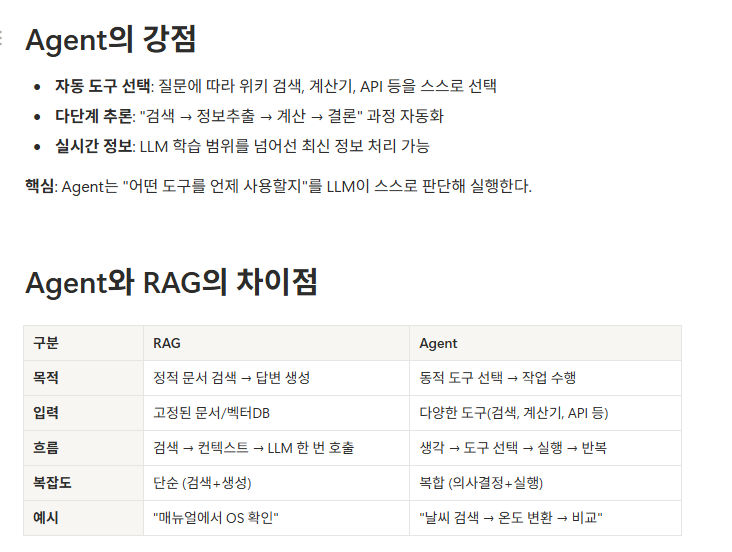

## 도구(Tool) 정의 하기

#### 문자열 길이를 계산하는 도구와 웹 검색 도구를 가진 Agent 만들기

### Agent의 동작 원리

LLM이 스스로 판단해서 준비된 도구(Tools)를 선택하고 사용하는 에이전트

#### **동작 흐름 (ReAct Loop)**

AgentExecutor가 루프를 돌며 다음 과정을 반복한다:

1. **Thought**: LLM이 "무엇을 해야 할지" 판단 (예: "검색 도구를 써야 해")
2. **Action**: 선택된 Tool 이름 결정
3. **Action Input**: Tool에 전달할 입력 생성
4. **Observation**: Tool 실행 결과 관찰
- Agent는 **단순 챗봇과 달리 외부 도구를 동적으로 사용**하며 복잡한 작업을 처리한다. verbose=True로 설정하면 콘솔에 각 단계가 출력되어 확인 가능하다.

In [170]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import create_react_agent

load_dotenv()

@tool
def add(a: int, b: int) -> int:
    """두 숫자를 더합니다."""
    return a + b
@tool
def get_word_length(word: str) -> int:
    """단어나 문장의 정확한 글자 수(길이)를 계산할 때 사용합니다."""
    return len(word)
# 클래스명 변경 및 객체 생성
search = TavilySearchResults(max_results=3)
@tool
def web_search(query: str) -> str:
    """웹 검색을 수행하는 도구입니다"""
    # TavilySearchResults의 실행 메서드는 .invoke()를 권장합니다.
    return search.invoke({"query": query})

# LLM 생성
llm = ChatOpenAI(model='gpt-5.5')  
tools = [add, get_word_length, web_search]

# 질문
query = "오늘 지금 한국시간 10시부터 시작한 대한민국 월드컵경기 결과를 예측해줘"

agent = create_react_agent(llm, tools=tools)

result = agent.invoke({"messages": [HumanMessage(content=query)]})
#print(result)
print("=== 에이전트 가동 ===")
print(result["messages"][-1].content)

C:\Users\KDA 25\AppData\Local\Temp\ipykernel_33104\3116058893.py:33: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools=tools)


=== 에이전트 가동 ===
예측으로는 **멕시코 2-1 대한민국**을 가장 유력하게 봅니다.

**예상 확률**
- 멕시코 승: 약 **45%**
- 무승부: 약 **30%**
- 대한민국 승: 약 **25%**

**이유**
- 경기가 멕시코에서 열리는 만큼 **홈 어드밴티지**가 큽니다.
- 멕시코는 전방 압박과 빠른 템포가 강점이라 한국 수비가 초반에 흔들릴 수 있습니다.
- 다만 한국도 손흥민·이강인 중심의 역습과 세트피스에서 득점 가능성이 충분합니다.
- 멕시코 수비 핵심 결장 변수가 있다면 한국이 한 골 이상 넣을 가능성은 꽤 높습니다.

**스코어 예측**
> 멕시코 2-1 대한민국

한국이 선제골을 넣거나 전반을 버티면 **1-1 무승부**도 충분히 가능한 경기라고 봅니다.
